In [ ]:
# Week 4 - Day 1 to 3
## Visualization & API Integration+

### Day 1 - Database Connection & Visualization Setup

In [1]:
import os

print("Available project files:")
for file in os.listdir():
    print(file)

Available project files:
.anaconda
.bash_history
.conda
.condarc
.continuum
.gitconfig
.ipynb_checkpoints
.ipython
.jupyter
.matplotlib
.ms-ad
.python_history
.redhat
.vscode
01_Dataset_Telco-Customer-Churn.csv
3D Objects
anaconda3
anaconda_projects
AppData
Application Data
bar.png
company_data_csv.csv
Contacts
Cookies
data_xlsx.xlsx
Desktop
Documents
Downloads
employee_data_csv.csv
expenses_data_csv.csv
Favorites
foodfile.csv
IntelGraphicsProfiles
IPL_Data_ Analytic_projects
Links
Local Settings
matplotlib.ipynb
Microsoft
Music
My Documents
NetHood
New folder
NTUSER.DAT
ntuser.dat.LOG1
ntuser.dat.LOG2
NTUSER.DAT{53b39e88-18c4-11ea-a811-000d3aa4692b}.TM.blf
NTUSER.DAT{53b39e88-18c4-11ea-a811-000d3aa4692b}.TMContainer00000000000000000001.regtrans-ms
NTUSER.DAT{53b39e88-18c4-11ea-a811-000d3aa4692b}.TMContainer00000000000000000002.regtrans-ms
ntuser.ini
null_data.csv
numpy.ipynb
OneDrive
pandas.ipynb
Pictures
PrintHood
python tutorial
Recent
Saved Games
seaborn.ipynb
Searches
SendTo
Start

In [2]:
import pandas as pd
import os

# Load the feature-engineered customer dataset
df = pd.read_csv("telco_customer_churn_feature_engineered.csv")

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset loaded successfully.
Dataset shape: (7043, 25)

Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'TotalChargesPerTenure', 'TenureGroup', 'MonthlyChargePerTenure', 'ChurnNumeric']


In [3]:
# Check data types and missing values

print("Data types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum().sort_values(ascending=False).head(10))

Data types:
customerID                 object
gender                     object
SeniorCitizen               int64
Partner                    object
Dependents                 object
tenure                      int64
PhoneService               object
MultipleLines              object
InternetService            object
OnlineSecurity             object
OnlineBackup               object
DeviceProtection           object
TechSupport                object
StreamingTV                object
StreamingMovies            object
Contract                   object
PaperlessBilling           object
PaymentMethod              object
MonthlyCharges            float64
TotalCharges              float64
Churn                      object
TotalChargesPerTenure     float64
TenureGroup                object
MonthlyChargePerTenure    float64
ChurnNumeric                int64
dtype: object

Missing values:
customerID                0
StreamingTV               0
MonthlyChargePerTenure    0
TenureGroup            

Churn
No     5174
Yes    1869
Name: count, dtype: int64


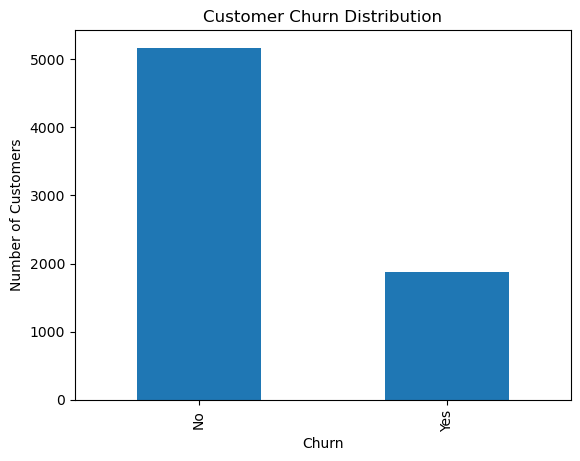

In [7]:
# Week 4 Day 1 - Basic Churn Visualization

import matplotlib.pyplot as plt

churn_counts = df['Churn'].value_counts()

print(churn_counts)

churn_counts.plot(kind='bar')

plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.show()

Churn             No   Yes
Contract                  
Month-to-month  2220  1655
One year        1307   166
Two year        1647    48


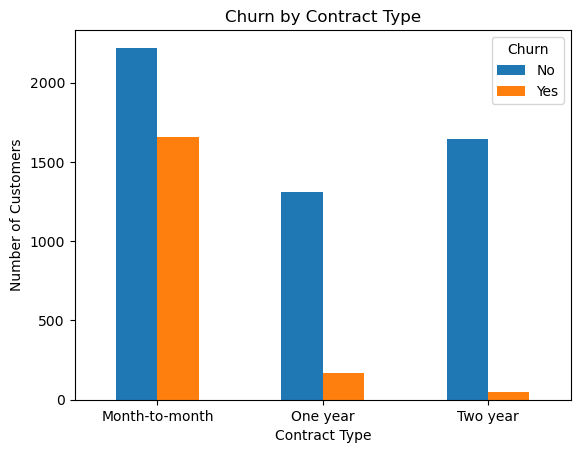

In [8]:
# Week 4 Day 1 - Contract-wise Churn Visualization

contract_churn = pd.crosstab(df['Contract'], df['Churn'])

print(contract_churn)

contract_churn.plot(kind='bar')

plt.title('Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.show()

Churn          No   Yes
TenureGroup            
0-1 Year     1149  1037
1-2 Years     730   294
2-4 Years    1269   325
4-5 Years     712   120
5-6 Years    1314    93


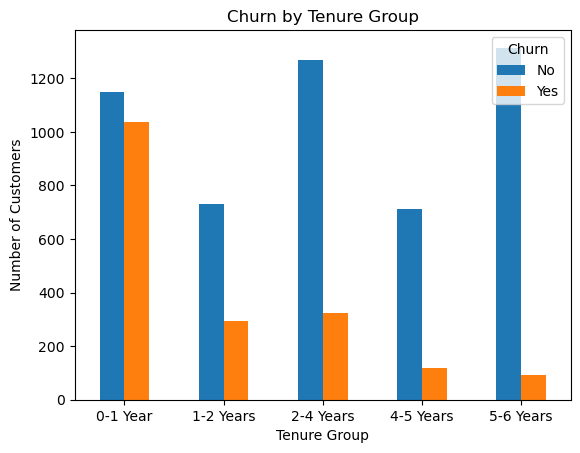

In [9]:
# Week 4 Day 1 - Tenure-wise Churn Visualization

tenure_churn = pd.crosstab(df['TenureGroup'], df['Churn'])

print(tenure_churn)

tenure_churn.plot(kind='bar')

plt.title('Churn by Tenure Group')
plt.xlabel('Tenure Group')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.show()

In [11]:
# Create Monthly Charges Groups

df['MonthlyChargeGroup'] = pd.cut(
    df['MonthlyCharges'],
    bins=[0, 30, 60, 90, float('inf')],
    labels=['Under 30', '30-59', '60-89', '90+']
)

print(df['MonthlyChargeGroup'].value_counts().sort_index())

MonthlyChargeGroup
Under 30    1653
30-59       1265
60-89       2386
90+         1739
Name: count, dtype: int64


Churn                 No  Yes
MonthlyChargeGroup           
Under 30            1491  162
30-59                937  328
60-89               1577  809
90+                 1169  570


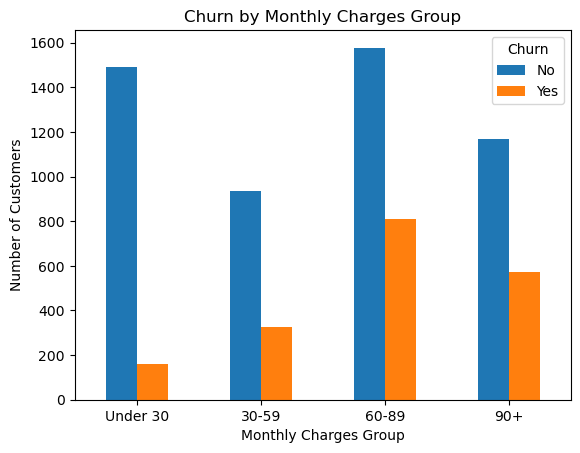

In [12]:
# Monthly Charges-wise Churn Visualization

monthly_churn = pd.crosstab(
    df['MonthlyChargeGroup'],
    df['Churn']
)

print(monthly_churn)

monthly_churn.plot(kind='bar')

plt.title('Churn by Monthly Charges Group')
plt.xlabel('Monthly Charges Group')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.show()

In [ ]:
# Week 4 Day 2: API Integration

In [4]:
# Week 4 - Day 2: API Integration

import requests

API_URL = "http://127.0.0.1:8000"

print("API URL:", API_URL)

API URL: http://127.0.0.1:8000


In [5]:
# Check API connection

try:
    response = requests.get(f"{API_URL}/")
    print("Status Code:", response.status_code)
    print("Response:", response.json())
except Exception as e:
    print("API connection failed:", e)

Status Code: 200
Response: {'message': 'Customer LTV Prediction API', 'status': 'running'}


In [10]:
# Test single customer prediction through API

import requests

API_URL = "http://127.0.0.1:8000"

customer_data = {
    "gender": "Female",
    "SeniorCitizen": 0,
    "Partner": "Yes",
    "Dependents": "No",
    "tenure": 12,
    "PhoneService": "Yes",
    "MultipleLines": "No",
    "InternetService": "DSL",
    "OnlineSecurity": "No",
    "OnlineBackup": "Yes",
    "DeviceProtection": "No",
    "TechSupport": "No",
    "StreamingTV": "No",
    "StreamingMovies": "No",
    "Contract": "Month-to-month",
    "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check",
    "MonthlyCharges": 70.0,
    "TotalCharges": 840.0
}

response = requests.post(
    f"{API_URL}/predict",
    json=customer_data
)

print("Status Code:", response.status_code)
print("Response Text:", response.text)

Status Code: 200
Response Text: {"predicted_ltv":4188.131734862445}
